# Supervised Learning I - K-Nearest Neighbors and Resampling Methods

## References

Chapters 4.7.1, 4.7.6, 5.3, [ISLP] An Introduction to Statistical Learning - with Applications in Python. Free access to download the book: https://www.statlearning.com/

<a target="_blank" href="https://colab.research.google.com/github/cspun/MLF/blob/JNB/sup-I.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [1]:
from IPython.display import HTML
HTML('''<script>
code_show_err=false; 
function code_toggle_err() {
 if (code_show_err){
 $('div.output_stderr').hide();
 } else {
 $('div.output_stderr').show();
 }
 code_show_err = !code_show_err
} 
$( document ).ready(code_toggle_err);
</script>
To toggle on/off output_stderr, click <a href="javascript:code_toggle_err()">here</a>.''')

## The Stock Market Data

We will examine the `Smarket` data, which is part of the `ISLP` library. This data set consists of percentage returns for the S&P 500 stock index over 1,250 days, from the beginning of 2001 until the end of 2005. For each date, we have recorded the percentage returns for each of the five previous trading days,  `Lag1`  through `Lag5`. We have also recorded  `Volume`  (the number of
shares traded on the previous day, in billions),  `Today`  (the percentage return on the date in question) and  `Direction`
(whether the market was  `Up`  or  `Down`  on this date).

We start by importing  our libraries at this top level; these are all imports we have seen in previous labs.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize)
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold

C:\Users\pig_p\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\pig_p\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


We also collect together the new imports needed for this lab.

In [3]:
from ISLP import confusion_table
from ISLP.models import contrast
from sklearn.discriminant_analysis import \
     (LinearDiscriminantAnalysis as LDA,
      QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

Now we are ready to load the `Smarket` data.

In [4]:
Smarket = load_data('Smarket')
Smarket

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,2001,0.381,-0.192,-2.624,-1.055,5.010,1.19130,0.959,Up
1,2001,0.959,0.381,-0.192,-2.624,-1.055,1.29650,1.032,Up
2,2001,1.032,0.959,0.381,-0.192,-2.624,1.41120,-0.623,Down
3,2001,-0.623,1.032,0.959,0.381,-0.192,1.27600,0.614,Up
4,2001,0.614,-0.623,1.032,0.959,0.381,1.20570,0.213,Up
...,...,...,...,...,...,...,...,...,...
1245,2005,0.422,0.252,-0.024,-0.584,-0.285,1.88850,0.043,Up
1246,2005,0.043,0.422,0.252,-0.024,-0.584,1.28581,-0.955,Down
1247,2005,-0.955,0.043,0.422,0.252,-0.024,1.54047,0.130,Up
1248,2005,0.130,-0.955,0.043,0.422,0.252,1.42236,-0.298,Down


This gives a truncated listing of the data.
We can see what the variable names are.

In [5]:
Smarket.columns

Index(['Year', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today',
       'Direction'],
      dtype='object')

We compute the correlation matrix using the `corr()` method
for data frames, which produces a matrix that contains all of
the pairwise correlations among the variables.
 
By instructing `pandas` to use only numeric variables, the `corr()` method does not report a correlation for the `Direction`  variable because it is
 qualitative.

In [6]:
Smarket.corr(numeric_only=True)

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000000,0.029700,0.030596,0.033195,0.035689,0.029788,0.539006,0.030095
Lag1,0.029700,1.000000,-0.026294,-0.010803,-0.002986,-0.005675,0.040910,-0.026155
Lag2,0.030596,-0.026294,1.000000,-0.025897,-0.010854,-0.003558,-0.043383,-0.010250
Lag3,0.033195,-0.010803,-0.025897,1.000000,-0.024051,-0.018808,-0.041824,-0.002448
Lag4,0.035689,-0.002986,-0.010854,-0.024051,1.000000,-0.027084,-0.048414,-0.006900
Lag5,0.029788,-0.005675,-0.003558,-0.018808,-0.027084,1.000000,-0.022002,-0.034860
Volume,0.539006,0.040910,-0.043383,-0.041824,-0.048414,-0.022002,1.000000,0.014592
Today,0.030095,-0.026155,-0.010250,-0.002448,-0.006900,-0.034860,0.014592,1.000000


As one would expect, the correlations between the lagged return  variables and
today’s return are close to zero.  The only substantial correlation is between  `Year`  and
 `Volume`. By plotting the data we see that  `Volume`
is increasing over time. In other words, the average number of shares traded
daily increased from 2001 to 2005.


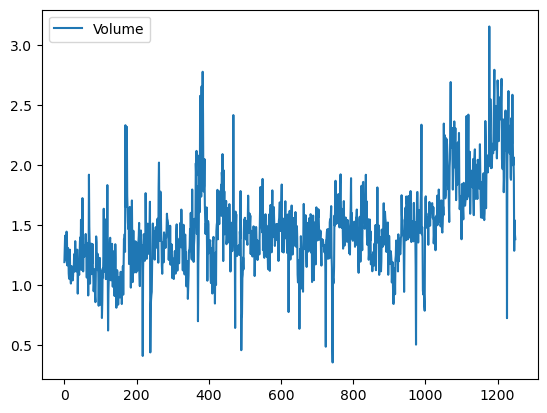

In [7]:
Smarket.plot(y='Volume');

In [8]:
train = (Smarket.Year < 2005)
# allvars = Smarket.columns.drop(['Today', 'Direction', 'Year'])
# design = MS(allvars)
# X = design.fit_transform(Smarket)
# X_train, X_test = X.loc[train], X.loc[~train]
model = MS(['Lag1', 'Lag2']).fit(Smarket)
X = model.transform(Smarket)
X_train, X_test = X.loc[train], X.loc[~train]
D = Smarket.Direction
y_train, y_test = D.loc[train], D.loc[~train]

## K-Nearest Neighbors
We will now perform KNN using the `KNeighborsClassifier()` function. We fit the classifier using the `fit` method. New predictions are formed using the `predict` method of the object returned by `fit()`.

In [9]:
knn1 = KNeighborsClassifier(n_neighbors=1)
X_train, X_test = [np.asarray(X) for X in [X_train, X_test]]
knn1.fit(X_train, y_train)
knn1_pred = knn1.predict(X_test)
confusion_table(knn1_pred, y_test)

Truth,Down,Up
Predicted,,
Down,43,58
Up,68,83


The results using $K=1$ are not very good, since only $50%$ of the observations are correctly predicted. Of course, it may be that $K=1$ results in an overly-flexible fit to the data.

In [10]:
np.mean(knn1_pred == y_test)

0.5

We repeat the
analysis below using $K=3$.

In [11]:
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3_pred = knn3.fit(X_train, y_train).predict(X_test)
np.mean(knn3_pred == y_test)

0.5317460317460317

The results have improved slightly. But increasing *K* further provides no further improvements.

KNN does not perform well on the `Smarket`  data, but it often does provide impressive results. As an example we will apply the KNN approach to the `Caravan`  data set, which is part of the `ISLP` library.  This data set includes 85 predictors that measure demographic characteristics for 5,822 individuals. The response variable is  `Purchase`, which indicates whether or not a given individual purchases a caravan insurance policy. In this data set, only 6% of people purchased caravan insurance.

In [12]:
Caravan = load_data('Caravan')
Purchase = Caravan.Purchase
Purchase.value_counts()

Purchase
No     5474
Yes     348
Name: count, dtype: int64

The method `value_counts()` takes a `pd.Series` or `pd.DataFrame` and returns
a `pd.Series` with the corresponding counts
for each unique element. In this case `Purchase` has only `Yes` and `No` values
and the method returns how many values of each there are.

In [13]:
348 / 5822

0.05977327378907592

Our features will include all columns except `Purchase`.

In [14]:
feature_df = Caravan.drop(columns=['Purchase'])

Because the KNN classifier predicts the class of a given test
observation by identifying the observations that are nearest to it,
the scale of the variables matters. Any variables that are on a large
scale will have a much larger effect on the *distance* between
the observations, and hence on the KNN classifier, than variables that
are on a small scale. For instance, imagine a data set that contains
two variables,  `salary`  and  `age`  (measured in dollars
and years, respectively). As far as KNN is concerned, a difference of
1,000 USD in salary is enormous compared to a difference of 50 years in
age. Consequently,  `salary`  will drive the KNN classification
results, and  `age`  will have almost no effect. This is contrary
to our intuition that a salary difference of 1,000 USD is quite small
compared to an age difference of 50 years.  Furthermore, the
importance of scale to the KNN classifier leads to another issue: if
we measured  `salary`  in Japanese yen, or if we measured
 `age`  in minutes, then we’d get quite different classification
results from what we get if these two variables are measured in
dollars and years.

A good way to handle this problem is to *standardize*  the data so that all variables are
given a mean of zero and a standard deviation of one. Then all
variables will be on a comparable scale. This is accomplished
using
the `StandardScaler()`
transformation.

Note that we cannot standardize the whole dataset and then split it into training and test data, because it leads to test data leakage to training data. We now first split the observations into a test set, containing the first 1,000 observations, and a training set, containing the remaining observations. Then we standardize the data with training data features' means and standard deviations. We fit a KNN model on the training data using $K=1$, and evaluate its performance on the test data.

In [15]:
X = feature_df
y = Purchase

# Split (note: OpenML returns default index; we rely on row order)
test_idx = np.arange(0, 1000)
train_idx = np.arange(1000, len(feature_df))

X_train = X.iloc[train_idx].copy()
X_test  = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test  = y.iloc[test_idx].copy()

# Standardize using only training data stats
scaler = StandardScaler(with_mean=True, with_std=True)
X_train_std = scaler.fit_transform(X_train)
X_test_std  = scaler.transform(X_test)

#### KNN with K = 1
We fit on the standardized training features and evaluate on the standardized test features.  
We report:
- Test error rate (`mean(y_pred != y_test)`), and
- A naive baseline that always predicts `No`.

In [16]:
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train_std, y_train)

y_pred_k1 = knn1.predict(X_test_std)
test_error_k1 = np.mean(y_pred_k1 != y_test)

# Baseline: always predict 'No'
baseline_pred = np.array(['No'] * len(y_test), dtype=object)
baseline_error = np.mean(baseline_pred != y_test.values)

test_error_k1, baseline_error

(0.117, 0.059)

The KNN error rate on the 1,000 test observations can look decent at first glance.  

However, if only ~6% of customers purchased insurance, **always predicting `No`** yields an error around 6%, which can outperform (or match) naïve KNN settings.

When there is a **cost** to contacting customers, it’s more relevant to measure success **among those predicted to buy** (i.e., precision for class `Yes`), not overall accuracy.

In [17]:
from sklearn.metrics import confusion_matrix

# Confusion matrix and success rate among those predicted 'Yes'
cm_k1 = confusion_matrix(y_test, y_pred_k1, labels=['No', 'Yes'])
cm_k1_df = pd.DataFrame(cm_k1, index=['Actual No', 'Actual Yes'], columns=['Pred No', 'Pred Yes'])

tp = cm_k1[1,1]  # actual Yes predicted Yes
pp = cm_k1[:,1].sum()  # total predicted Yes
success_rate_k1 = (tp / pp) if pp > 0 else np.nan

cm_k1_df, success_rate_k1

(            Pred No  Pred Yes
 Actual No       874        67
 Actual Yes       50         9,
 0.11842105263157894)

In the R notes, among those predicted to buy (e.g., 77 customers), around 11–12% actually purchase—**about double** the population base rate (~6%). Your exact counts may differ slightly due to environment, preprocessing, or dataset versioning, but the interpretation is the same: **KNN finds signal** among the predicted positives.

#### KNN with K = 3 and K = 5
We repeat the analysis for K=3 and K=5 and compute the success rate among predicted `Yes` (precision).

In [18]:
def success_rate_among_pred_yes(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=['No', 'Yes'])
    tp = cm[1,1]
    pp = cm[:,1].sum()
    return (tp / pp) if pp > 0 else np.nan, pd.DataFrame(
        cm, index=['Actual No', 'Actual Yes'], columns=['Pred No', 'Pred Yes']
    )

results = {}

for k in [3, 5]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_std, y_train)
    y_pred = knn.predict(X_test_std)
    sr, cm_df = success_rate_among_pred_yes(y_test, y_pred)
    results[k] = {
        'success_rate_among_pred_yes': sr,
        'confusion_matrix': cm_df,
        'test_error': float(np.mean(y_pred != y_test))
    }

results

{3: {'success_rate_among_pred_yes': 0.2222222222222222,
  'confusion_matrix':             Pred No  Pred Yes
  Actual No       920        21
  Actual Yes       53         6,
  'test_error': 0.074},
 5: {'success_rate_among_pred_yes': 0.23076923076923078,
  'confusion_matrix':             Pred No  Pred Yes
  Actual No       931        10
  Actual Yes       56         3,
  'test_error': 0.066}}

In the R notes, the success rate for K=3 and K=5 rises to ~23%, **over four times** the base rate of ~6%, indicating KNN is capturing real patterns.

One practical caveat: for some K (e.g., K=5), the number of customers predicted as purchasers can be quite **small**, which limits outreach volume even if precision is high.  

In practice, you might:
- Tune K using cross-validation to balance precision and volume,
- Adjust decision thresholds using distances or class probabilities (e.g., from other models),
- Combine KNN with cost-sensitive selection to meet campaign constraints.

## Resampling Methods

In practice, we often need to evaluate model performance and choose the best model among candidates. Resampling methods provide tools for estimating the test error, which helps us avoid overfitting and improves generalization. We illustrate these methods using the `Smarket` dataset with KNN classification, and later with bootstrap and (over/under)sampling examples.

In [19]:
train_mask = Smarket['Year'] < 2005
train_X = Smarket.loc[train_mask, ['Lag1', 'Lag2']].to_numpy()
test_X  = Smarket.loc[~train_mask, ['Lag1', 'Lag2']].to_numpy()
train_y = Smarket.loc[train_mask, 'Direction'].to_numpy()
test_y  = Smarket.loc[~train_mask, 'Direction'].to_numpy()
ntrain = train_X.shape[0]
ntrain

998

### Validation-set Approach

The validation-set approach involves splitting the available data into two parts: a training set and a validation (test) set. The model is trained on the training set and evaluated on the validation set.

Below we randomly select 70% of the **training portion** for model fitting and use the remaining 30% for validation. We then compute validation error rates for different values of `k` in KNN.

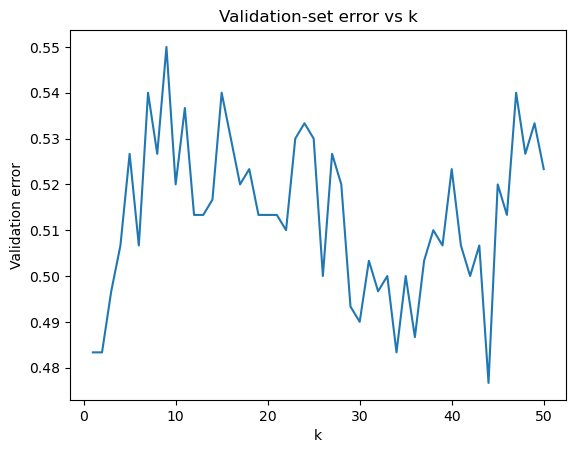

44

In [20]:
rng = np.random.default_rng(1)

idx = np.arange(ntrain)
rng.shuffle(idx)

cut = int(0.7 * ntrain)
pdtrain_idx = idx[:cut]
pdtest_idx  = idx[cut:]

pdtrain_X = train_X[pdtrain_idx]
pdtest_X  = train_X[pdtest_idx]
pdtrain_y = train_y[pdtrain_idx]
pdtest_y  = train_y[pdtest_idx]

Kmax = 50
ErrTe = np.zeros(Kmax, dtype=float)

for k in range(1, Kmax+1):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(pdtrain_X, pdtrain_y)
    pred = knn.predict(pdtest_X)
    ErrTe[k-1] = np.mean(pred != pdtest_y)

plt.plot(np.arange(1, Kmax+1), ErrTe)
plt.xlabel("k")
plt.ylabel("Validation error")
plt.title("Validation-set error vs k")
plt.show()

best_k = np.argmin(ErrTe) + 1
best_k

The plot shows how the error rate changes with `k`. `best_k` is the `k` with the lowest validation error. Repeating the split with a different random seed may yield a different “optimal” `k`, indicating that the validation-set approach can be unstable.

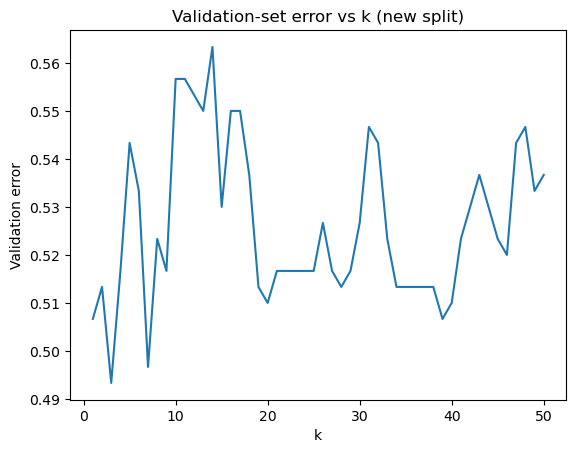

3

In [21]:
rng = np.random.default_rng(2)  # new seed

idx = np.arange(ntrain)
rng.shuffle(idx)

cut = int(0.7 * ntrain)
pdtrain_idx = idx[:cut]
pdtest_idx  = idx[cut:]

pdtrain_X = train_X[pdtrain_idx]
pdtest_X  = train_X[pdtest_idx]
pdtrain_y = train_y[pdtrain_idx]
pdtest_y  = train_y[pdtest_idx]

ErrTe2 = np.zeros(Kmax, dtype=float)
for k in range(1, Kmax+1):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(pdtrain_X, pdtrain_y)
    pred = knn.predict(pdtest_X)
    ErrTe2[k-1] = np.mean(pred != pdtest_y)

plt.plot(np.arange(1, Kmax+1), ErrTe2)
plt.xlabel("k")
plt.ylabel("Validation error")
plt.title("Validation-set error vs k (new split)")
plt.show()

best_k2 = np.argmin(ErrTe2) + 1
best_k2

### F-fold Cross Validation
To obtain a more reliable estimate, we can use `k`-fold cross validation. The data is split into `F` roughly equal parts (“folds”). Each fold is used once as a validation set, while the other folds form the training set. The test errors are averaged across folds.

Here, we use 10-fold cross validation on the **training portion** of the data and evaluate K from 1 to 50.


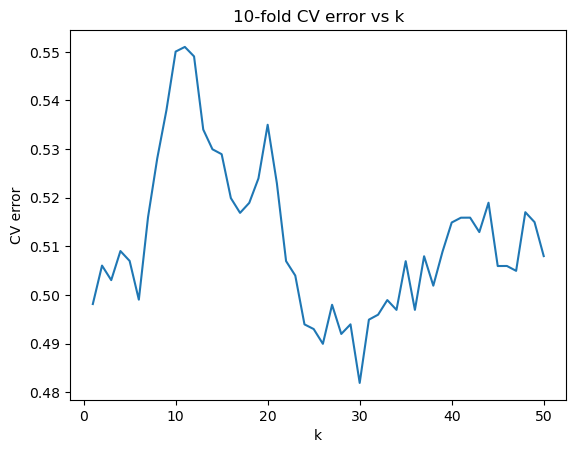

30

In [22]:
F = 10
kf = KFold(n_splits=F, shuffle=True, random_state=1)

Kmax = 50
ErrCV = np.zeros((F, Kmax), dtype=float)

for fold_id, (tr_idx, va_idx) in enumerate(kf.split(train_X)):
    X_tr, X_va = train_X[tr_idx], train_X[va_idx]
    y_tr, y_va = train_y[tr_idx], train_y[va_idx]

    for k in range(1, Kmax+1):
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_tr, y_tr)
        pred = knn.predict(X_va)
        ErrCV[fold_id, k-1] = np.mean(pred != y_va)

CV = ErrCV.mean(axis=0)

plt.plot(np.arange(1, Kmax+1), CV)
plt.xlabel("k")
plt.ylabel("CV error")
plt.title("10-fold CV error vs k")
plt.show()

best_k_cv = np.argmin(CV) + 1
best_k_cv

The resulting curve is typically smoother than the validation-set approach. `best_k_cv` gives the best choice of `k` by CV.

### Bootstrap
Bootstrap is another powerful resampling technique. Instead of splitting data into folds, we generate many bootstrap datasets by sampling **with replacement** from the training set. Each bootstrap dataset is the same size as the original, but contains duplicate observations. This allows us to estimate variability of a statistic or model parameter.

In [23]:
# Create one bootstrap sample of row indices from the training set
BSind = np.random.default_rng(0).integers(low=0, high=ntrain, size=ntrain, endpoint=False)
BSdata = train_X[BSind]
BSdata.shape

(998, 2)

In [24]:
# Generate multiple bootstrap datasets (skeleton)
B = 100
rng_bs = np.random.default_rng(1)
boot_means = []

for b in range(B):
    BSind = rng_bs.integers(low=0, high=ntrain, size=ntrain, endpoint=False)
    BS_X = train_X[BSind]
    # ... perform analyses on BS_X (and corresponding y if needed) ...
    # Example placeholder: store a statistic (mean of Lag1 here just as a demo)
    boot_means.append(BS_X[:, 0].mean())

np.mean(boot_means), np.std(boot_means, ddof=1)

(0.005984709418837674, 0.039074516403285235)

Bootstrap is particularly useful for estimating the standard error of model parameters when no analytical formula is available.

### Oversampling and Undersampling (Iris subset)
In imbalanced classification problems, where one class is much rarer than the other, resampling techniques can create a more balanced dataset.

We illustrate this with a subset of the Iris dataset containing only *setosa* (majority) and *versicolor* (minority): rows 1–50 are setosa, 51–100 are versicolor, 101–150 are virginica. We take the first 75 rows (50 setosa + 25 versicolor).

In [25]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
iris_df = iris.frame.copy()
iris_df['target'] = iris_df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

irisdata = iris_df.iloc[:75].copy()  # 50 setosa + 25 versicolor
irisdata = irisdata[irisdata['target'].isin(['setosa', 'versicolor'])].copy()
irisdata['target'] = irisdata['target'].astype('category')

n = len(irisdata)
major_idx = irisdata.index[irisdata['target'] == 'setosa']
minor_idx = irisdata.index[irisdata['target'] == 'versicolor']
majorn = len(major_idx)
minorn = len(minor_idx)

majorn, minorn

(50, 25)

**Oversampling** duplicates minority-class samples until class sizes are equal.

In [26]:
rng_os = np.random.default_rng(42)
need = majorn - minorn
OS_pick = rng_os.choice(minor_idx.to_numpy(), size=need, replace=True)
OSdata = pd.concat([irisdata, irisdata.loc[OS_pick]], ignore_index=True)

iris_counts = irisdata['target'].value_counts()
os_counts = OSdata['target'].value_counts()
iris_counts, os_counts

(target
 setosa        50
 versicolor    25
 Name: count, dtype: int64,
 target
 setosa        50
 versicolor    50
 Name: count, dtype: int64)

**Undersampling** removes majority-class samples to match the minority-class size.

In [27]:
rng_us = np.random.default_rng(43)
drop = rng_us.choice(major_idx.to_numpy(), size=(majorn - minorn), replace=False)
USdata = irisdata.drop(index=drop).copy()

us_counts = USdata['target'].value_counts()
iris_counts, us_counts

(target
 setosa        50
 versicolor    25
 Name: count, dtype: int64,
 target
 setosa        25
 versicolor    25
 Name: count, dtype: int64)

*Note.* Oversampling can increase the risk of overfitting (by repeating minority examples), while undersampling may discard useful information from the majority class.

### SMOTE (Synthetic Minority Oversampling Technique)
In imbalanced classification problems, simply duplicating minority-class examples (oversampling) can lead to overfitting, while discarding majority-class examples (undersampling) may waste information. **SMOTE** provides an alternative by generating *synthetic minority* observations via interpolation between existing minority samples and their nearest neighbors.

Here we apply SMOTE using `imbalanced-learn` on the same imbalanced Iris subset (setosa = majority, versicolor = minority).

In [28]:
# uncomment in a notebook if needed
# pip install imbalanced-learn  

In [29]:
from imblearn.over_sampling import SMOTE

X_iris = irisdata[iris.feature_names].to_numpy()
y_iris = irisdata['target'].to_numpy()

print("Original distribution:")
print(pd.Series(y_iris).value_counts())

sm = SMOTE(k_neighbors=5, sampling_strategy='auto', random_state=1)
X_sm, y_sm = sm.fit_resample(X_iris, y_iris)

print("\nAfter SMOTE:")
print(pd.Series(y_sm).value_counts())

Original distribution:
setosa        50
versicolor    25
Name: count, dtype: int64

After SMOTE:
setosa        50
versicolor    50
Name: count, dtype: int64


C:\Users\pig_p\anaconda3\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Here:
- `k_neighbors=5` specifies the number of neighbors used to synthesize new minority points.
- `sampling_strategy='auto'` balances the classes by oversampling the minority to match the majority.

SMOTE creates more diverse samples than random oversampling, but if classes overlap significantly, synthetic points can fall into ambiguous regions. Use care when decision boundaries are not well-separated.